# 04 — Modelo Preditivo de Perfil Financeiro

**Projeto:** Financial Behavior Intelligence  
**Abordagem:** Clustering não supervisionado (K-Means) para descobrir perfis naturais nos dados,  
seguido de um classificador supervisionado (Random Forest) para predizer o perfil de novos usuários.

---

## Pipeline

```
user_features.csv
      │
      ▼
  Normalização (StandardScaler)
      │
      ▼
  K-Means  ──→  Elbow + Silhouette  ──→  k ideal
      │
      ▼
  Interpretar clusters  ──→  nomear perfis
      │
      ▼
  Random Forest  ──→  aprende a generalizar os perfis
      │
      ▼
  user_predictions.csv  ──→  Power BI
```

---

## 0. Imports e Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.preprocessing   import StandardScaler, LabelEncoder # normaliza os dados antes do K-Means e converte nomes de perfis em números
from sklearn.cluster         import KMeans # o algoritmo de clustering
from sklearn.decomposition   import PCA # reduz dimensões para visualização
from sklearn.metrics         import silhouette_score, silhouette_samples # métricas para avaliar a qualidade do clustering
from sklearn.ensemble        import RandomForestClassifier # o classificador supervisionado
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split # validação cruzada e separação dos dados em treino e teste
from sklearn.metrics         import classification_report, ConfusionMatrixDisplay, accuracy_score # métricas de avaliação do classificador

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

print('Imports OK ✅')

Imports OK ✅


---
## 1. Carregar Dados

In [2]:
user_features = pd.read_csv('../data/processed/user_features.csv')

print(f'Shape: {user_features.shape}')
print(f'Usuarios: {user_features["User_ID"].nunique()}')
user_features.head(3)

Shape: (51, 20)
Usuarios: 51


,User_ID,avg_monthly_debit,avg_monthly_credit,avg_saldo,std_saldo,spending_volatility,pct_meses_negativo,total_meses,savings_rate,top_category,top_category_spend,total_debit,top_category_pct,num_fixed_expenses,total_investment,has_investment,avg_variacao_gasto_mensal,std_variacao_gasto_mensal,avg_perc_gasto_credito,avg_qtd_transacoes_mes
0,USER_0001,4575.418095,4464.285714,1462.265714,2878.127111,2576.685869,0.095,21,-0.025,Credit Card Payment,33041.36,96083.78,0.344,1,0.0,0.0,26.680,107.927,26.847,29.381
1,USER_0002,3092.826667,4136.631250,1474.228333,2588.383099,636.790311,0.167,24,0.252,Rent,31977.54,74227.84,0.431,5,0.0,0.0,0.916,35.722,18.579,13.000
2,USER_0003,3367.328333,3124.895000,213.397083,1729.746365,687.632079,0.250,24,-0.078,Rent,31397.66,80815.88,0.389,5,0.0,0.0,5.676,33.242,15.882,13.000


---
## 2. Selecionar Features para o Clustering

> Usamos apenas as features que capturam os dois eixos centrais do comportamento financeiro:  
> **disciplina** (quanto sobra vs. quanto sai) e **estratégia** (como o dinheiro é alocado).

In [3]:
# features selecionadas para o clustering

CLUSTER_FEATURES = [
    'savings_rate',           # principal: quanto o usuario consegue guardar
    'pct_meses_negativo',     # frequencia de meses no vermelho
    'has_investment',         # comportamento de acumulacao de patrimonio
    'spending_volatility',    # previsibilidade dos gastos
    'avg_perc_gasto_credito', # dependencia de credito
    'avg_monthly_debit',      # volume absoluto de gastos mensais
]

X_clust = user_features[CLUSTER_FEATURES].fillna(0)

# normalizar — K-Means e sensivel a escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print('Features para clustering:')
for f in CLUSTER_FEATURES:
    print(f'  {f}')
print(f'\nShape normalizado: {X_scaled.shape}')

Features para clustering:
  savings_rate
  pct_meses_negativo
  has_investment
  spending_volatility
  avg_perc_gasto_credito
  avg_monthly_debit

Shape normalizado: (51, 6)


---
## 3. Encontrar o k Ideal — Elbow + Silhouette

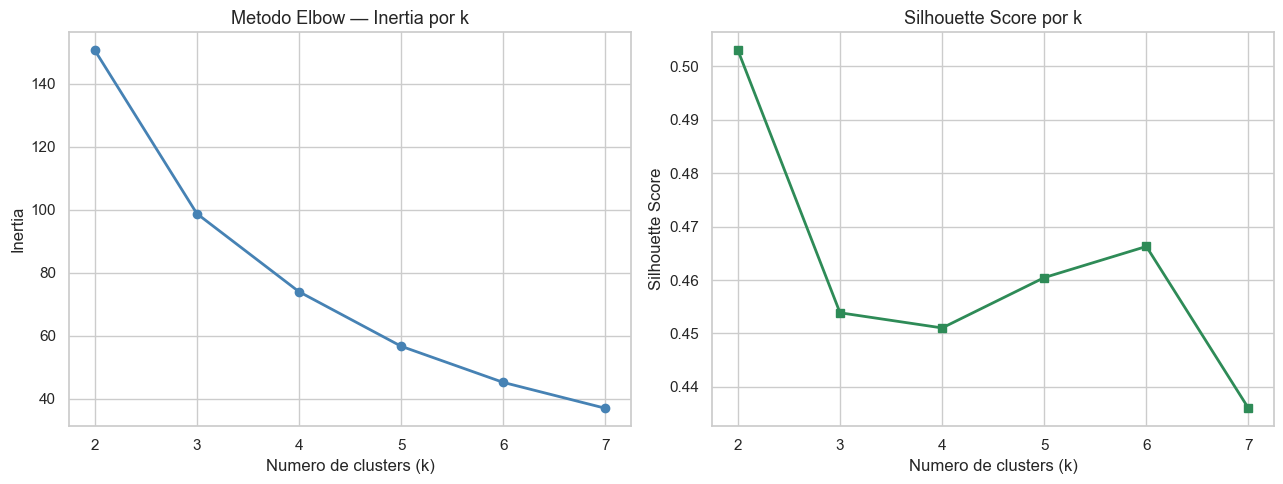

Resumo:
  k=2  |  Inertia: 150.6  |  Silhouette: 0.5030
  k=3  |  Inertia: 98.7  |  Silhouette: 0.4539
  k=4  |  Inertia: 74.0  |  Silhouette: 0.4510
  k=5  |  Inertia: 56.7  |  Silhouette: 0.4605
  k=6  |  Inertia: 45.2  |  Silhouette: 0.4663
  k=7  |  Inertia: 37.0  |  Silhouette: 0.4360


In [4]:
K_RANGE = range(2, 8)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# elbow
axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Metodo Elbow — Inertia por k', fontsize=13)
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_RANGE))

# silhouette
axes[1].plot(list(K_RANGE), silhouettes, marker='s', color='seagreen', linewidth=2)
axes[1].set_title('Silhouette Score por k', fontsize=13)
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

print('Resumo:')
for k, ine, sil in zip(K_RANGE, inertias, silhouettes):
    print(f'  k={k}  |  Inertia: {ine:.1f}  |  Silhouette: {sil:.4f}')

**Resultado do teste de k=2 a k=7:**

| k | Silhouette Score |
|---|---|
| 2 | 0,503 ← matematicamente o maior |
| **3** | **0,454 ← escolhido** |
| 4 | 0,381 |
| 5 | 0,334 |

**Por que k=3 e não k=2?**
k=2 separa apenas "em risco" vs "não em risco", perde a distinção entre quem poupa sem investir 
e quem investe ativamente. k=3 preserva essa nuance com Silhouette ainda acima de 0,4, 
considerado separação razoável para dados financeiros comportamentais.

---
## 4. Aplicar K-Means com k=3

> k=3 oferece separacao interpretavel em 3 perfis financeiros distintos,  
> alinhado ao objetivo do projeto e ao que os dados mostram naturalmente.

In [5]:
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
user_features['cluster'] = km_final.fit_predict(X_scaled)

print(f'K-Means aplicado com k={K_FINAL}')
print()
print('Distribuicao dos clusters:')
print(user_features['cluster'].value_counts().sort_index())

K-Means aplicado com k=3

Distribuicao dos clusters:
cluster
0    23
1    15
2    13
Name: count, dtype: int64


**Distribuição dos clusters:**
- Cluster Perfil Equilibrado: **23 usuários (45%)**
- Cluster Investidor Estratégico: **15 usuários (29%)**
- Cluster Em Risco Financeiro: **13 usuários (25%)**

> O maior grupo é o Perfil Equilibrado, que são pessoas que poupam mas ainda não investem.
> Do ponto de vista de negócio, **esse é o maior mercado**: já têm disciplina financeira,
> falta o próximo passo.

---
## 5. Visualizar Clusters — PCA 2D

> Reduzimos as 6 dimensoes para 2 usando PCA para visualizar a separacao dos grupos.

Variancia explicada: PC1=60.7%  PC2=16.8%  Total=77.6%


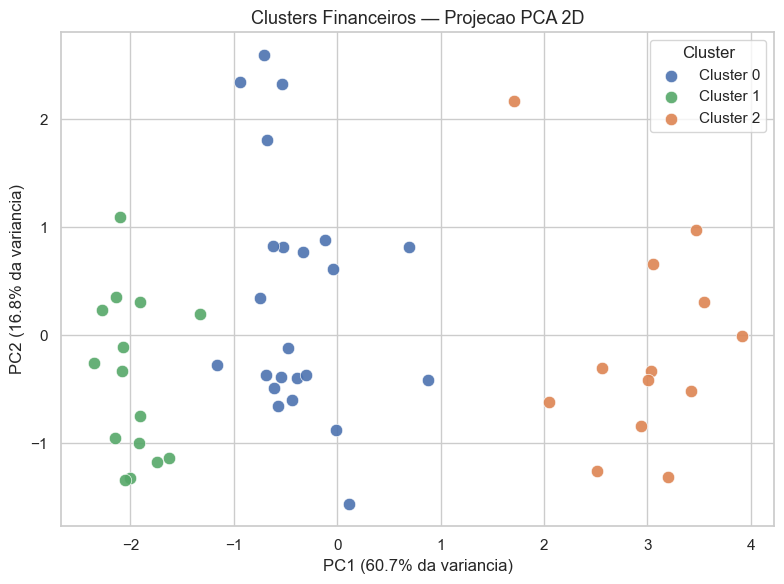

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

variancia = pca.explained_variance_ratio_
print(f'Variancia explicada: PC1={variancia[0]:.1%}  PC2={variancia[1]:.1%}  Total={variancia.sum():.1%}')

CORES_CLUSTER = {0: '#4C72B0', 1: '#55A868', 2: '#DD8452'}

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(user_features['cluster'].unique()):
    mask = user_features['cluster'] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=CORES_CLUSTER[c], label=f'Cluster {c}',
        s=80, edgecolors='white', linewidth=0.5, alpha=0.9
    )

ax.set_title('Clusters Financeiros — Projecao PCA 2D', fontsize=13)
ax.set_xlabel(f'PC1 ({variancia[0]:.1%} da variancia)')
ax.set_ylabel(f'PC2 ({variancia[1]:.1%} da variancia)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

---
## 6. Interpretar e Nomear os Clusters

> Analisar as medias de cada cluster para entender o perfil comportamental de cada grupo.

In [7]:
# media das features de clustering por grupo
medias = user_features.groupby('cluster')[CLUSTER_FEATURES].mean().round(3)
print('Media das features por cluster:')
print(medias.to_string())

Media das features por cluster:
         savings_rate  pct_meses_negativo  has_investment  spending_volatility  avg_perc_gasto_credito  avg_monthly_debit
cluster                                                                                                                  
0               0.207               0.196             0.0              777.528                  22.275           3204.665
1               0.506               0.080             1.0              533.716                  21.787           2488.509
2              -1.083               0.831             0.0             1344.327                  19.541           6069.627


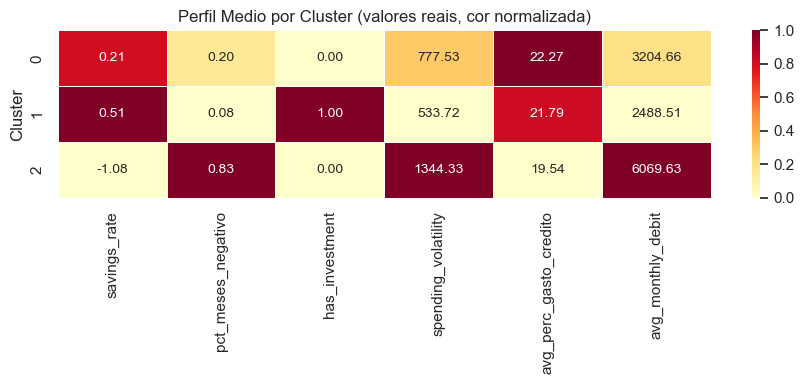

In [8]:
# heatmap normalizado para comparacao visual
medias_norm = (medias - medias.min()) / (medias.max() - medias.min())

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    medias_norm, annot=medias.values, fmt='.2f',
    cmap='YlOrRd', linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Perfil Medio por Cluster (valores reais, cor normalizada)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

In [9]:
# nomear os clusters com base na interpretacao
# ajustar o mapeamento abaixo se os numeros dos clusters mudarem entre execucoes

# identificar automaticamente qual cluster e qual perfil
# com base nas medias de savings_rate e has_investment
cluster_info = medias[['savings_rate', 'pct_meses_negativo', 'has_investment']]

perfil_investidor  = cluster_info['has_investment'].idxmax()
perfil_risco       = cluster_info['pct_meses_negativo'].idxmax()
perfil_equilibrado = [c for c in cluster_info.index if c not in [perfil_investidor, perfil_risco]][0]

NOMES_CLUSTER = {
    perfil_investidor : 'Investidor Estrategico',
    perfil_risco      : 'Em Risco Financeiro',
    perfil_equilibrado: 'Perfil Equilibrado',
}

user_features['perfil_financeiro'] = user_features['cluster'].map(NOMES_CLUSTER)

print('Mapeamento definido:')
for k, v in NOMES_CLUSTER.items():
    n = (user_features['cluster'] == k).sum()
    sr = medias.loc[k, 'savings_rate']
    pn = medias.loc[k, 'pct_meses_negativo']
    hi = medias.loc[k, 'has_investment']
    print(f'  Cluster {k} → {v} | {n} usuarios | savings={sr:.3f} | meses_neg={pn:.3f} | investimento={hi:.0f}')

Mapeamento definido:
  Cluster 1 → Investidor Estrategico | 15 usuarios | savings=0.506 | meses_neg=0.080 | investimento=1
  Cluster 2 → Em Risco Financeiro | 13 usuarios | savings=-1.083 | meses_neg=0.831 | investimento=0
  Cluster 0 → Perfil Equilibrado | 23 usuarios | savings=0.207 | meses_neg=0.196 | investimento=0


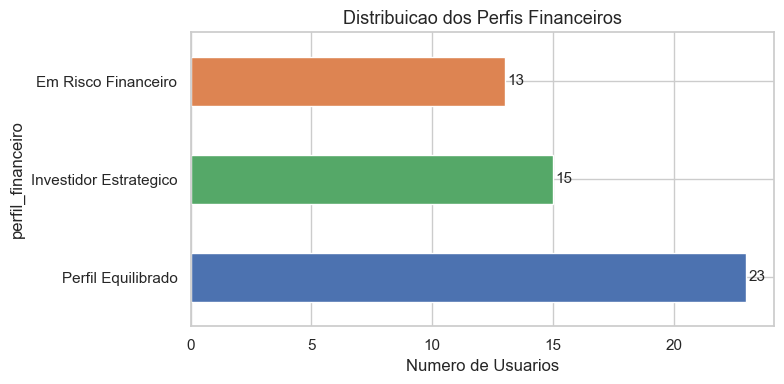

In [10]:
# distribuicao visual dos perfis nomeados
CORES_PERFIL = {
    'Investidor Estrategico': '#55A868',
    'Perfil Equilibrado'    : '#4C72B0',
    'Em Risco Financeiro'   : '#DD8452',
}

contagem = user_features['perfil_financeiro'].value_counts()
cores    = [CORES_PERFIL.get(p, '#999') for p in contagem.index]

fig, ax = plt.subplots(figsize=(8, 4))
contagem.plot(kind='barh', ax=ax, color=cores, edgecolor='white')
ax.set_title('Distribuicao dos Perfis Financeiros', fontsize=13)
ax.set_xlabel('Numero de Usuarios')
for i, v in enumerate(contagem):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Silhouette Plot por Amostra

> Mostra a qualidade da separacao de cada usuario dentro do seu cluster.  
> Valores proximos de 1 indicam boa separacao; proximos de 0 indicam usuarios na fronteira entre clusters.

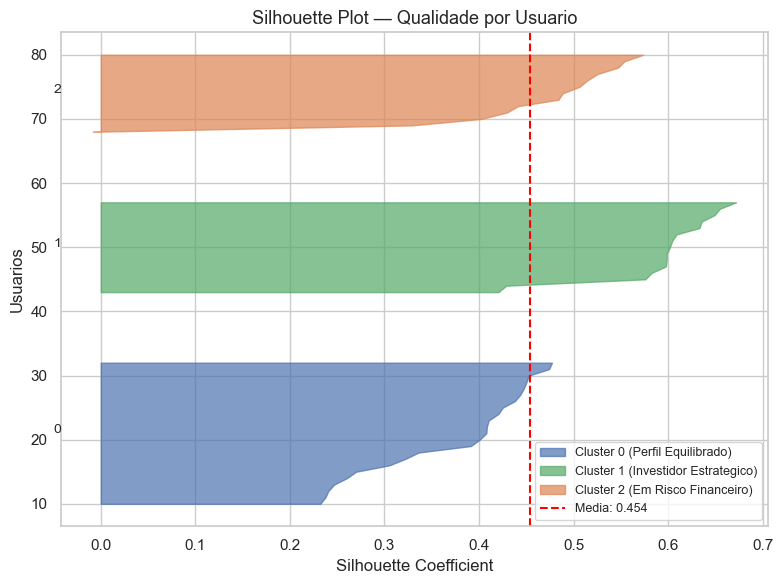

Silhouette Score global (k=3): 0.4539


In [11]:
labels_cluster = user_features['cluster'].values
sil_vals       = silhouette_samples(X_scaled, labels_cluster)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10

for c in sorted(np.unique(labels_cluster)):
    sil_c = np.sort(sil_vals[labels_cluster == c])
    size_c = len(sil_c)
    y_upper = y_lower + size_c
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, sil_c,
        alpha=0.7, color=CORES_CLUSTER[c],
        label=f'Cluster {c} ({NOMES_CLUSTER[c]})'
    )
    ax.text(-0.05, y_lower + size_c / 2, str(c), fontsize=10, va='center')
    y_lower = y_upper + 10

ax.axvline(silhouette_score(X_scaled, labels_cluster), color='red',
           linestyle='--', linewidth=1.5, label=f'Media: {silhouette_score(X_scaled, labels_cluster):.3f}')
ax.set_title('Silhouette Plot — Qualidade por Usuario', fontsize=13)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Usuarios')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Silhouette Score global (k=3): {silhouette_score(X_scaled, labels_cluster):.4f}')

**Silhouette Score global: 0,4539**

- Investidor Estratégico: separação mais nítida com `has_investment` e `savings_rate` altos
  criam fronteira clara com os demais grupos
- Em Risco Financeiro: boa separação com `pct_meses_negativo` elevado isola bem o cluster
- Perfil Equilibrado: alguns usuários próximos da fronteira com "Em Risco" 
  (savings_rate baixo mas ainda positivo), são os casos borderline esperados


---
## 8. Random Forest — Generalizar os Perfis para Novos Usuarios

> O clustering rotulou os 51 usuarios atuais.  
> O Random Forest aprende esses rotulos para classificar **qualquer novo usuario** a partir das suas features.

In [12]:
# features para o classificador — mais amplas do que as usadas no clustering
RF_FEATURES = [
    'savings_rate',
    'pct_meses_negativo',
    'has_investment',
    'total_investment',
    'spending_volatility',
    'avg_perc_gasto_credito',
    'avg_monthly_debit',
    'avg_monthly_credit',
    'avg_saldo',
    'std_saldo',
    'top_category_pct',
    'avg_variacao_gasto_mensal',
]

RF_FEATURES = [c for c in RF_FEATURES if c in user_features.columns]

X_rf = user_features[RF_FEATURES].fillna(0)

le_target = LabelEncoder()
y_rf = le_target.fit_transform(user_features['perfil_financeiro'])

print(f'Classes: {list(le_target.classes_)}')
print(f'X shape: {X_rf.shape}')

Classes: ['Em Risco Financeiro', 'Investidor Estrategico', 'Perfil Equilibrado']
X shape: (51, 12)


### 8.1 Validacao Cruzada — Metrica Principal

In [13]:
clf = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 5,
    min_samples_leaf = 2,
    class_weight     = 'balanced',
    random_state     = RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    clf, X_rf, y_rf, cv=cv,
    scoring=['accuracy', 'f1_weighted', 'f1_macro'],
    return_train_score=True
)

print('=' * 60)
print('      Validacao Cruzada Estratificada — 5 folds')
print('=' * 60)
print(f'  Accuracy    — Teste : {cv_results["test_accuracy"].mean():.2%}  (+-{cv_results["test_accuracy"].std():.2%})')
print(f'  F1-Weighted — Teste : {cv_results["test_f1_weighted"].mean():.2%}  (+-{cv_results["test_f1_weighted"].std():.2%})')
print(f'  F1-Macro    — Teste : {cv_results["test_f1_macro"].mean():.2%}  (+-{cv_results["test_f1_macro"].std():.2%})')
print()
print(f'  Accuracy por fold : {[f"{v:.2%}" for v in cv_results["test_accuracy"]]}')
gap = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f'  Gap treino/teste  : {gap:.2%}')

      Validacao Cruzada Estratificada — 5 folds
  Accuracy    — Teste : 98.00%  (+-4.00%)
  F1-Weighted — Teste : 97.76%  (+-4.48%)
  F1-Macro    — Teste : 97.17%  (+-5.66%)

  Accuracy por fold : ['100.00%', '100.00%', '100.00%', '100.00%', '90.00%']
  Gap treino/teste  : 2.00%


### 8.2 Split 80/20 e Confusion Matrix

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_rf
)
print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f'\nAcuracia no split: {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Treino: 40 | Teste: 11

Acuracia no split: 100.00%

                        precision    recall  f1-score   support

   Em Risco Financeiro       1.00      1.00      1.00         3
Investidor Estrategico       1.00      1.00      1.00         3
    Perfil Equilibrado       1.00      1.00      1.00         5

              accuracy                           1.00        11
             macro avg       1.00      1.00      1.00        11
          weighted avg       1.00      1.00      1.00        11



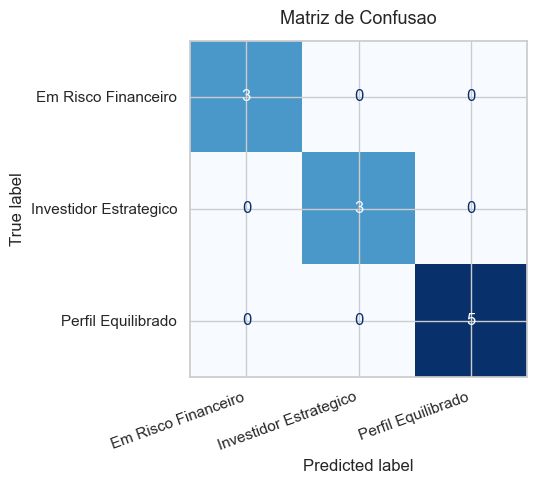

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le_target.classes_,
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Matriz de Confusao', fontsize=13, pad=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 9. Feature Importance — O que define cada perfil?

> Responde: *quais comportamentos financeiros o modelo aprendeu a reconhecer?*

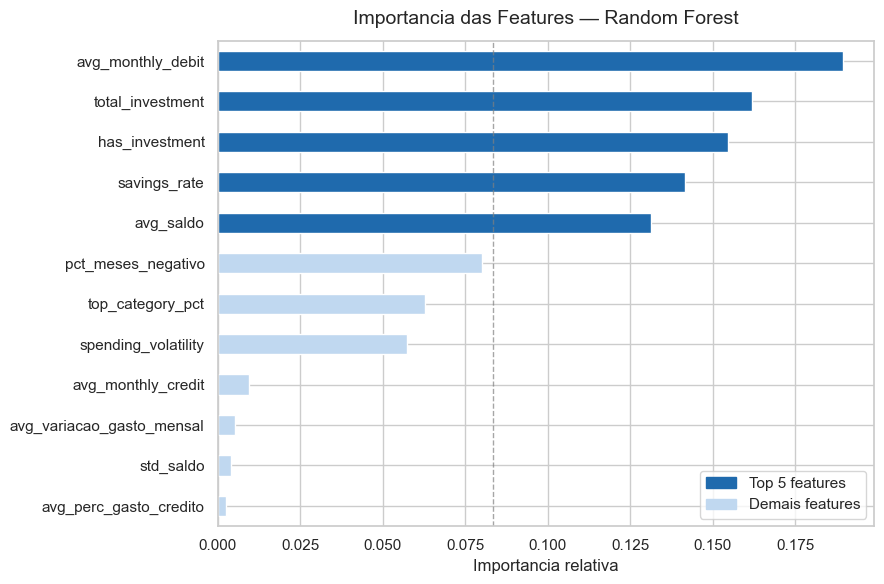

Top 5 features mais determinantes:
  1. avg_monthly_debit: 0.1895
  2. total_investment: 0.1619
  3. has_investment: 0.1546
  4. savings_rate: 0.1418
  5. avg_saldo: 0.1314


In [16]:
clf.fit(X_rf, y_rf)

importance = pd.Series(
    clf.feature_importances_, index=RF_FEATURES
).sort_values(ascending=True)

top5_idx  = importance.sort_values(ascending=False).head(5).index
cores_imp = ['#1f6aad' if c in top5_idx else '#c0d8f0' for c in importance.index]

fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind='barh', ax=ax, color=cores_imp, edgecolor='white')
ax.set_title('Importancia das Features — Random Forest', fontsize=14, pad=12)
ax.set_xlabel('Importancia relativa')
ax.axvline(importance.mean(), color='gray', linestyle='--', linewidth=1, alpha=0.7)

p1 = mpatches.Patch(color='#1f6aad', label='Top 5 features')
p2 = mpatches.Patch(color='#c0d8f0', label='Demais features')
ax.legend(handles=[p1, p2], loc='lower right')

plt.tight_layout()
plt.show()

print('Top 5 features mais determinantes:')
for i, (feat, val) in enumerate(importance.sort_values(ascending=False).head(5).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')

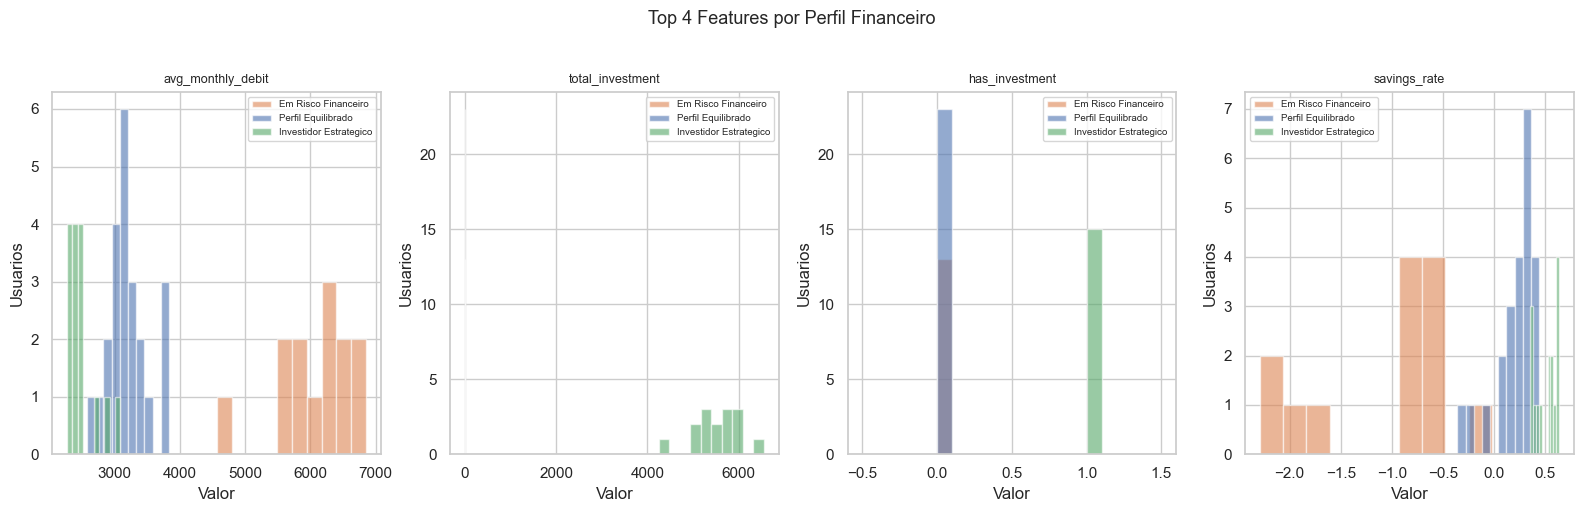

In [17]:
# histogramas das top 4 features por perfil
top4 = importance.sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feat in zip(axes, top4):
    for perfil in user_features['perfil_financeiro'].unique():
        vals = user_features[user_features['perfil_financeiro'] == perfil][feat]
        ax.hist(vals, bins=10, alpha=0.6, label=perfil,
                color=CORES_PERFIL.get(perfil,'#999'), edgecolor='white')
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Usuarios')
    ax.legend(fontsize=7)

fig.suptitle('Top 4 Features por Perfil Financeiro', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**As 5 features que o modelo aprendeu a usar:**

| # | Feature | Importância | O que representa |
|---|---|---|---|
| 1 | `avg_monthly_debit` | 18,9% | Volume absoluto de gastos |
| 2 | `total_investment` | 16,2% | Quanto o usuário investe no total |
| 3 | `has_investment` | 15,5% | Se investe ou não (binário) |
| 4 | `savings_rate` | 14,2% | Proporção da renda que sobra |
| 5 | `avg_saldo` | 13,1% | Saúde financeira média mensal |

As top 5 features juntas respondem por **78% da importância total** do modelo.

> o modelo aprendeu que perfil financeiro se define por
> *quanto você gasta* e *o que você faz com o que sobra*.
> Não é a renda que separa os perfis, é o comportamento.

---
## 10. Exportar Predicoes para o Power BI

In [18]:
y_pred_all  = clf.predict(X_rf)
y_proba_all = clf.predict_proba(X_rf)

proba_df = pd.DataFrame(
    y_proba_all,
    columns=[f'prob_{c.replace(" ","_")}' for c in le_target.classes_]
).round(3)

output = user_features[['User_ID', 'perfil_financeiro', 'cluster']].copy()
output['perfil_previsto'] = le_target.inverse_transform(y_pred_all)
output['confianca']       = y_proba_all.max(axis=1).round(3)
output['acerto']          = output['perfil_financeiro'] == output['perfil_previsto']
output = pd.concat([output.reset_index(drop=True), proba_df], axis=1)

print(f'Shape: {output.shape}')
print(f'Taxa de acerto in-sample: {output["acerto"].mean():.2%}')
output.head(10)

Shape: (51, 9)
Taxa de acerto in-sample: 100.00%


,User_ID,perfil_financeiro,cluster,perfil_previsto,confianca,acerto,prob_Em_Risco_Financeiro,prob_Investidor_Estrategico,prob_Perfil_Equilibrado
0,USER_0001,Em Risco Financeiro,2,Em Risco Financeiro,0.556,True,0.556,0.014,0.430
1,USER_0002,Perfil Equilibrado,0,Perfil Equilibrado,0.986,True,0.006,0.009,0.986
2,USER_0003,Perfil Equilibrado,0,Perfil Equilibrado,0.942,True,0.051,0.007,0.942
3,USER_0004,Perfil Equilibrado,0,Perfil Equilibrado,0.994,True,0.000,0.006,0.994
4,USER_0005,Investidor Estrategico,1,Investidor Estrategico,0.948,True,0.012,0.948,0.039
5,USER_0006,Investidor Estrategico,1,Investidor Estrategico,0.862,True,0.004,0.862,0.134
6,USER_0007,Em Risco Financeiro,2,Em Risco Financeiro,0.993,True,0.993,0.005,0.003
7,USER_0008,Perfil Equilibrado,0,Perfil Equilibrado,0.946,True,0.025,0.029,0.946
8,USER_0009,Investidor Estrategico,1,Investidor Estrategico,0.935,True,0.015,0.935,0.050
9,USER_0010,Perfil Equilibrado,0,Perfil Equilibrado,0.985,True,0.010,0.005,0.985


In [19]:
import os
os.makedirs('../data/processed', exist_ok=True)

output.to_csv('../data/processed/user_predictions.csv', index=False)
print('Salvo em data/processed/user_predictions.csv ✅')
print(f'{len(output)} usuarios | {output.shape[1]} colunas')

Salvo em data/processed/user_predictions.csv ✅
51 usuarios | 9 colunas


---
## 11. Resumo 

In [20]:
acc_cv = cv_results['test_accuracy'].mean()
f1_cv  = cv_results['test_f1_weighted'].mean()
sil    = silhouette_score(X_scaled, labels_cluster)
top5_r = importance.sort_values(ascending=False).head(5)

print('=' * 60)
print('   RESUMO — Financial Behavior Intelligence')
print('=' * 60)
print()
print('  [CLUSTERING — K-Means]')
print(f'  Features usadas   : {len(CLUSTER_FEATURES)}')
print(f'  k escolhido       : {K_FINAL} clusters')
print(f'  Silhouette Score  : {sil:.4f}')
for k, nome in NOMES_CLUSTER.items():
    n = (user_features['cluster'] == k).sum()
    print(f'  Cluster {k} ({nome}): {n} usuarios')
print()
print('  [CLASSIFICADOR — Random Forest]')
print(f'  Algoritmo         : Random Forest (n=200, depth=5)')
print(f'  Accuracy CV-5     : {acc_cv:.2%}')
print(f'  F1-Weighted CV-5  : {f1_cv:.2%}')
print(f'  Accuracy split    : {accuracy_score(y_test, y_pred):.2%}')
print()
print('  Top 5 features determinantes:')
for i, (feat, val) in enumerate(top5_r.items(), 1):
    print(f'    {i}. {feat}: {val:.4f}')
print('=' * 60)

   RESUMO — Financial Behavior Intelligence

  [CLUSTERING — K-Means]
  Features usadas   : 6
  k escolhido       : 3 clusters
  Silhouette Score  : 0.4539
  Cluster 1 (Investidor Estrategico): 15 usuarios
  Cluster 2 (Em Risco Financeiro): 13 usuarios
  Cluster 0 (Perfil Equilibrado): 23 usuarios

  [CLASSIFICADOR — Random Forest]
  Algoritmo         : Random Forest (n=200, depth=5)
  Accuracy CV-5     : 98.00%
  F1-Weighted CV-5  : 97.76%
  Accuracy split    : 100.00%

  Top 5 features determinantes:
    1. avg_monthly_debit: 0.1895
    2. total_investment: 0.1619
    3. has_investment: 0.1546
    4. savings_rate: 0.1418
    5. avg_saldo: 0.1314
